<a href="https://colab.research.google.com/github/TaShapovalova/my-colab-project/blob/main/Copy_%F0%9F%8D%80of_%D0%9A%D0%BE%D0%BF%D0%B8%D1%8F_%D0%B1%D0%BB%D0%BE%D0%BA%D0%BD%D0%BE%D1%82%D0%B0_%22price_tags_example_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div class="markdown-google-sans">

## <strong>Импорт необходимых библиотек, модели для обучения, а также распаковка набора данных</strong>
</div>

In [ ]:
from IPython.display import clear_output
import cv2
!pip3 install google-colab
from google.colab.patches import cv2_imshow
clear_output()

In [ ]:
# Скачивание репозитория с YOLOv5 и необходимых библиотек для работы модели
!git clone https://github.com/ultralytics/yolov5
!pip install -r ./yolov5/requirements.txt
# clear_output()

Cloning into 'yolov5'...
remote: Enumerating objects: 18420, done.
remote: Counting objects: 100% (80/80), done.
remote: Compressing objects: 100% (56/56), done.
remote: Total 18420 (delta 53), reused 24 (delta 24), pack-reused 18340 (from 3)
Receiving objects: 100% (18420/18420), 17.52 MiB | 15.68 MiB/s, done.
Resolving deltas: 100% (12510/12510), done.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.1/131.1 kB 11.1 MB/s eta 0:00:00
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.5.0
    Uninstalling urllib3-2.5.0:
      Successfully uninstalled urllib3-2.5.0


In [ ]:
!rm ./yolov5/data/custom.yaml

In [ ]:
# Создаём файл для собственной структуры датасета
!touch ./yolov5/data/custom.yaml

In [ ]:
# Примерная структура датасета. в случае если называете директории по другому, измените их название

# В СЛУЧАЕ РАЗМЕТКИ НА ROBOFLOW ИЗМЕНИТЕ СТРОКУ С ИМЕНАМИ КЛАССОВ НА ТУ, ЧТО УКАЗАНА В ФАЙЛЕ "data.yaml", КОТОРЫЙ СКАЧИВАЕТСЯ ВМЕСТЕ С НАБОРОМ ДАННЫХ
text="""
train: ../price_tags/images/train/
val:  ../price_tags/images/val/
test: ../price_tags/images/test/
# number of classes
nc: 4
# class names
names: ['price_card_kop', 'price_card_rub', 'price_kop', 'price_rub']
"""

# Записываем в созданный ранее файл структуру датасете
my_file = open('/content/yolov5/data/custom.yaml','w+')
# my_file.write('train: ../price_tags/images/train/ \nval:  ../price_tags/images/val/ \ntest: ../price_tags/images/test/ \n# number of classes \nnc: 4 \n# class names \nnames: ["price_rub", "price_kop", "price_card_rub", "price_card_kop"]')
my_file.write(text)

211

In [ ]:
# Проверка записи в файл структуры. Если вывод пустой, повторно запустите предыдущую ячейку
my_file.readlines()

[]

In [ ]:
from google.colab import drive
import os
import glob

drive.mount('/content/gdrive')
root = '/gdrive/My Drive/'

Mounted at /content/gdrive


In [ ]:
# !unzip '/content/priceTagsShort.zip' -d /content/
# !unzip '/content/yolo5_tags.zip' -d /content/
# !unzip '/content/price_tags.zip' -d /content/
# !unzip '/content/tags.zip' -d /content/
!unzip '/content/gdrive/MyDrive/work/price_tags.zip' -d /content/

unzip:  cannot find or open /content/gdrive/MyDrive/work/price_tags.zip, /content/gdrive/MyDrive/work/price_tags.zip.zip or /content/gdrive/MyDrive/work/price_tags.zip.ZIP.


In [ ]:
!pip install imageio
!pip install imutils
clear_output()

In [ ]:
import random
from PIL import Image, ImageDraw
import numpy as np
from numpy import int64
import matplotlib.pyplot as plt
import os
import glob
from imageio import imread
import cv2
from google.colab.patches import cv2_imshow
import imutils
import json

import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras.applications import VGG16, VGG19
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.preprocessing.image import load_img
from sklearn.model_selection import train_test_split
from tensorflow.keras import backend as K

import torch
from IPython.display import Image
import os
import random
import shutil
from sklearn.model_selection import train_test_split
import xml.etree.ElementTree as ET
from xml.dom import minidom
from tqdm import tqdm
from PIL import Image, ImageDraw
import numpy as np
import matplotlib.pyplot as plt

ERROR:absl:Detected incompatible Protobuf Gencode/Runtime versions when loading tensorflow_metadata/proto/v0/anomalies.proto: gencode 6.31.1 runtime 5.29.6. Runtime version cannot be older than the linked gencode version. See Protobuf version guarantees at https://protobuf.dev/support/cross-version-runtime-guarantee.
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/__init__.py", line 79, in <module>
    from tensorflow_datasets import rlds  # pylint: disable=g-bad-import-order
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/rlds/__init__.py", line 21, in <module>
    from tensorflow_datasets.rlds import envlogger_reader
  File "/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/rlds/envlogger_reader.py", line 21, in <module>
    from tensorflow_datasets.core.utils.lazy_imports_utils import tree
  File "/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/co

<div class="markdown-google-sans">

## <strong>Предобработка датасета</strong>
</div>

In [ ]:
# Функция для копирования файлов
def move_files_to_folder(list_of_files, destination_folder):
    for f in list_of_files:
        try:
            shutil.copy(f, destination_folder)
        except:
            print(f)
            assert False

In [ ]:
# Создаём папки для хранения датасета на "внешнем" хранилище, чтобы можно было их изменять
!mkdir ./yolov5/price_tags
!mkdir ./yolov5/price_tags/images ./yolov5/price_tags/labels

In [ ]:
import os
import zipfile
import shutil
from google.colab import drive

# 1. Подключаем Диск
try: drive.mount('/content/drive')
except: print("Диск уже готов")

# Создаем чистые папки
shutil.rmtree('/content/yolov5/price_tags', ignore_errors=True)
os.makedirs('/content/yolov5/price_tags/images', exist_ok=True)
os.makedirs('/content/yolov5/price_tags/labels', exist_ok=True)

# 2. Распаковываем картинки
images_zip = "/content/drive/MyDrive/price_tags.zip"
with zipfile.ZipFile(images_zip, 'r') as zip_ref:
    for file in zip_ref.namelist():
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            filename = os.path.basename(file)
            if filename:
                with open(os.path.join('/content/yolov5/price_tags/images', filename), 'wb') as f:
                    f.write(zip_ref.read(file))

# 3. Распаковываем разметку (точно под твое имя на Диске lableimg.zip)
labels_zip = "/content/drive/MyDrive/lableimg.zip"
with zipfile.ZipFile(labels_zip, 'r') as zip_ref:
    for file in zip_ref.namelist():
        if file.lower().endswith('.txt') and not file.startswith('_MACOSX'):
            filename = os.path.basename(file)
            if filename:
                with open(os.path.join('/content/yolov5/price_tags/labels', filename), 'wb') as f:
                    f.write(zip_ref.read(file))

print(f"Итого картинок в YOLO: {len(os.listdir('/content/yolov5/price_tags/images'))}")
print(f"Итого файлов разметки в YOLO: {len(os.listdir('/content/yolov5/price_tags/labels'))}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Итого картинок в YOLO: 51
Итого файлов разметки в YOLO: 1


In [ ]:
import os

# Принудительно создаем структуру папок, если её нет
os.makedirs('/content/yolov5/data', exist_ok=True)

yaml_text = """
path: /content/yolov5/price_tags
train: images
val: images
test: images

nc: 4
names: ['price_card_kop', 'price_card_rub', 'price_kop', 'price_rub']
"""

with open('/content/yolov5/data/custom.yaml', 'w', encoding='utf-8') as f:
    f.write(yaml_text.strip())

print("Файл custom.yaml успешно создан!")

Файл custom.yaml успешно создан!


In [ ]:
# 1. Принудительно очищаем старую пустую папку и качаем заново
!rm -rf /content/yolov5_official
!git clone --depth 1 https://github.com /content/yolov5_official

# 2. Устанавливаем библиотеки
!pip install -q -r /content/yolov5_official/requirements.txt

# 3. Копируем наш файл конфигурации
!mkdir -p /content/yolov5_official/data
!cp /content/yolov5/data/custom.yaml /content/yolov5_official/data/custom.yaml

# 4. Переходим в нужную папку и запускаем обучение на 80 эпох
%cd /content/yolov5_official
!python train.py --img 640 --batch 16 --epochs 80 --data /content/yolov5_official/data/custom.yaml --weights yolov5s.pt --cache

shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
Cloning into '/content/yolov5_official'...
fatal: Unable to read current working directory: No such file or directory
shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
The folder you are executing pip from can no longer be found.
shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
/content/yolov5_official
python3: can't open file '/content/yolov5_official/train.py': [Errno 2] No such file or directory


In [ ]:
# 1. Скачиваем официальный и рабочий репозиторий YOLOv5
!rm -rf /content/yolov5_official
!git clone https://github.com /content/yolov5_official

# 2. Устанавливаем официальные библиотеки
!pip install -q -r /content/yolov5_official/requirements.txt

# 3. Копируем файл конфигурации, который ты создала в ячейке выше
!cp /content/yolov5/data/custom.yaml /content/yolov5_official/data/custom.yaml

shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
Cloning into '/content/yolov5_official'...
fatal: Unable to read current working directory: No such file or directory
shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
The folder you are executing pip from can no longer be found.
shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
cp: cannot create regular file '/content/yolov5_official/data/custom.yaml': No such file or directory


In [ ]:
# originImgs = "../content/yolo5_tags/images/"
# originLabls = "../content/yolo5_tags/labels/"

originImgs = "../content/images/"
originLabls = "../content/labels/"

# originImgs = "../content/tags/images/"
# originLabls = "../content/tags/labels/"

# Создаём пустые списки для хранения путей к изображениям и разметкам
images = []
annotations = []

# Копируем изображения из "внутреннего" датасета в ранее созданные папки
for fl in sorted(os.listdir(originImgs)):
    images.append(originImgs+fl)
move_files_to_folder(images, "./yolov5/price_tags/images/")
for fl in sorted(os.listdir(originLabls)):
    annotations.append(originLabls+fl)
move_files_to_folder(annotations, "./yolov5/price_tags/labels/")

FileNotFoundError: [Errno 2] No such file or directory: '../content/images/'

In [ ]:
import os
import shutil

# Пути к папкам, куда мы распаковали архивы в самом начале
my_images = '/content/yolov5/price_tags/images/'
my_labels = '/content/yolov5/price_tags/labels/'

# Целевые папки внутри официального репозитория YOLOv5
target_images = '/content/yolov5_official/data/images/'
target_labels = '/content/yolov5_official/data/labels/'

os.makedirs(target_images, exist_ok=True)
os.makedirs(target_labels, exist_ok=True)

# Копируем картинки
for f in os.listdir(my_images):
    shutil.copy(os.path.join(my_images, f), target_images)

# Копируем разметку
for f in os.listdir(my_labels):
    shutil.copy(os.path.join(my_labels, f), target_labels)

print(f"Картинок для обучения готово: {len(os.listdir(target_images))}")
print(f"Файлов разметки готово: {len(os.listdir(target_labels))}")

Картинок для обучения готово: 51
Файлов разметки готово: 1


In [ ]:
# Проверка наличия файлов. Количество файлов должно совпадать
!ls ./yolov5/price_tags/labels/
print('-----------------')
!ls ./yolov5/price_tags/images/

photo-100-_jpg.rf.b0d21ea23e9f3f5ed435ac0c45e734a2.txt
photo-101-_jpg.rf.df5d3985dbb70567d7e7420019a0cfdf.txt
photo-102-_jpg.rf.81fc7b334dc4e1717ae4e2f064322b7f.txt
photo-103-_jpg.rf.0a4c2da1c38d7f2acf8c214af82d1ed5.txt
photo-104-_jpg.rf.7667272395a37d41d52f0ac699f8df39.txt
photo-105-_jpg.rf.e7ba0d8ab69487be6e980abb95a6091c.txt
photo-106-_jpg.rf.85cd86d987e94b04b732f21739ab01f4.txt
photo-107-_jpg.rf.ab4f777eb89afeadf1e6b46971ba2429.txt
photo-108-_jpg.rf.c4f388c4ca03e1b42122a16d01c83b6e.txt
photo-109-_jpg.rf.5560fcf6555a1594073d08cbdc96df21.txt
photo-10-_jpg.rf.3375cd0d988f6e886765ef1c17cc1951.txt
photo-110-_jpg.rf.5f81d6ba591ca70f56164bf71cbb83e7.txt
photo-111-_jpg.rf.3e949ccba1674614314f81048208b112.txt
photo-112-_jpg.rf.dafb1bd956107bae58bc3b4de1d4f865.txt
photo-113-_jpg.rf.ee02d29059a2a5e7880aa275578743bf.txt
photo-114-_jpg.rf.55e616912b771968c7777a3faadf66b5.txt
photo-115-_jpg.rf.65d4da2aaa9995c885eb1d997bd28f9a.txt
photo-116-_jpg.rf.a71be5259f288dcb0f1f5c693e08adbc.txt
photo-117-_

../content/labels/photo-120-_jpg.rf.a46aac9715c94e510e36ab6e7edfd28c.txt


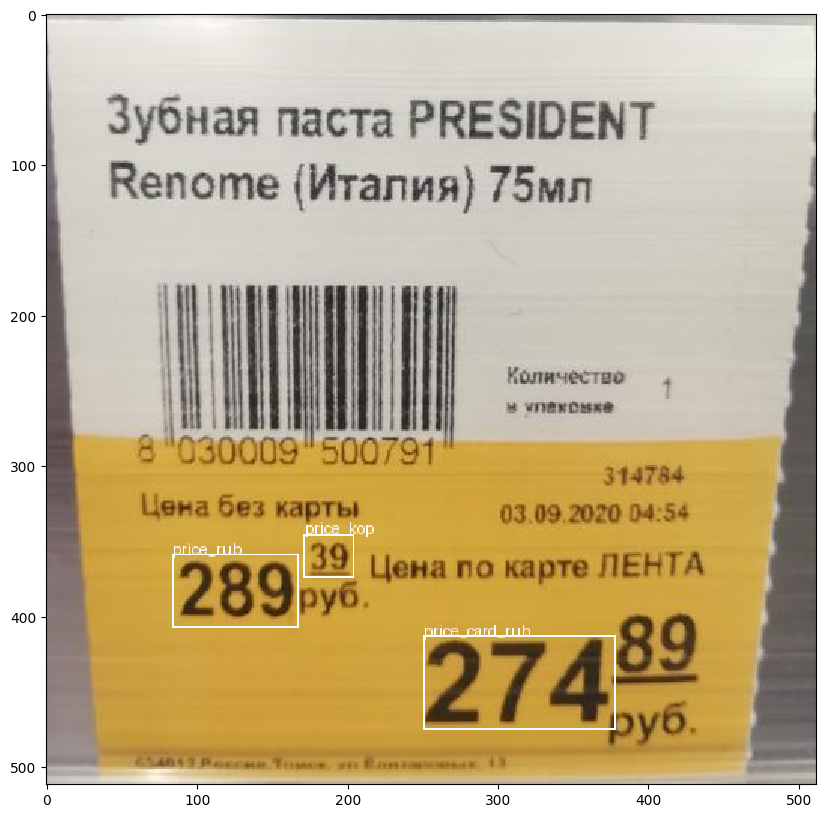

In [ ]:
# Определение id классов объектов
class_name_to_id_mapping = {"price_rub": 3,
                            "price_kop": 2,
                            "price_card_rub": 1,
                            "price_card_kop": 0}

# Установка сида рандомной генерации
random.seed(0)

# Определяем словарь с id классов
class_id_to_name_mapping = dict(zip(class_name_to_id_mapping.values(), class_name_to_id_mapping.keys()))

# Функция для демонстрации разметки
def plot_bounding_box(image, annotation_list):
    annotations = np.array(annotation_list)

    # Получаем размер изображения
    w, h = image.size

    # Выводим исходное изображение
    plotted_image = ImageDraw.Draw(image)

    # Конвертируем координаты для показа
    transformed_annotations = np.copy(annotations)
    transformed_annotations[:,[1,3]] = annotations[:,[1,3]] * w
    transformed_annotations[:,[2,4]] = annotations[:,[2,4]] * h

    transformed_annotations[:,1] = transformed_annotations[:,1] - (transformed_annotations[:,3] / 2)
    transformed_annotations[:,2] = transformed_annotations[:,2] - (transformed_annotations[:,4] / 2)
    transformed_annotations[:,3] = transformed_annotations[:,1] + transformed_annotations[:,3]
    transformed_annotations[:,4] = transformed_annotations[:,2] + transformed_annotations[:,4]

    # Вывод разметки и классов объектов
    for ann in transformed_annotations:
        obj_cls, x0, y0, x1, y1 = ann
        plotted_image.rectangle(((x0,y0), (x1,y1)))

        plotted_image.text((x0, y0 - 10), class_id_to_name_mapping[(int(obj_cls))])

    plt.figure(figsize = (30,10))
    plt.imshow(np.array(image), interpolation='nearest')
    plt.show()

# Выбираем случайный файл разметки
annotation_file = random.choice(annotations)
print(annotation_file)
with open(annotation_file, "r") as file:
    annotation_list = file.read().split("\n")[:-1]
    annotation_list = [x.split(" ") for x in annotation_list]
    annotation_list = [[float(y) for y in x ] for x in annotation_list]

# Получаем соответствующий файл с разметкой
image_file = annotation_file.replace("labels", "images").replace("txt", "jpg")
assert os.path.exists(image_file)

# Загрузка изображения
image = Image.open(image_file)

# Показ разметки
plot_bounding_box(image, annotation_list)

Вариация верхнего блока, но для вывода разметки всех изображений датасета

**Запускать на свой страх и риск, или только в случае необходимости наглядной проверки разметки, ибо из-за большого количества изображений может зависнуть браузер**

In [ ]:
# Определение id классов объектов
class_name_to_id_mapping = {"price_rub": 0,
                            "price_kop": 1,
                            "price_card_rub": 2,
                            "price_card_kop": 3}

# Установка сида рандомной генерации
random.seed(0)

# Определяем словарь с id классов
class_id_to_name_mapping = dict(zip(class_name_to_id_mapping.values(), class_name_to_id_mapping.keys()))

# Функция для демонстрации разметки
def plot_bounding_box(image, annotation_list):
    annotations = np.array(annotation_list)

    # Получаем размер изображения
    w, h = image.size

    # Выводим исходное изображение
    plotted_image = ImageDraw.Draw(image)

    # Конвертируем координаты для показа
    transformed_annotations = np.copy(annotations)
    transformed_annotations[:,[1,3]] = annotations[:,[1,3]] * w
    transformed_annotations[:,[2,4]] = annotations[:,[2,4]] * h

    transformed_annotations[:,1] = transformed_annotations[:,1] - (transformed_annotations[:,3] / 2)
    transformed_annotations[:,2] = transformed_annotations[:,2] - (transformed_annotations[:,4] / 2)
    transformed_annotations[:,3] = transformed_annotations[:,1] + transformed_annotations[:,3]
    transformed_annotations[:,4] = transformed_annotations[:,2] + transformed_annotations[:,4]

    # Вывод разметки и классов объектов
    for ann in transformed_annotations:
        obj_cls, x0, y0, x1, y1 = ann
        plotted_image.rectangle(((x0,y0), (x1,y1)))

        plotted_image.text((x0, y0 - 10), class_id_to_name_mapping[(int(obj_cls))])

    plt.figure(figsize = (30,10))
    plt.imshow(np.array(image), interpolation='nearest')
    plt.show()

# Получаем путь к каждому файлу разметки из списка
for annotation_file in annotations:
  # Открываем файл в режиме чтения
  with open(annotation_file, "r") as file:
    # Разделяем весь текст в файле по строчно
    annotation_list = file.read().split("\n")[:-1]
    # Разделяем кажду строку на отедльные координаты и класс, ориентируясь на пробелы
    annotation_list = [x.split(" ") for x in annotation_list]
    # Переводим координаты в числовой вид
    annotation_list = [[float(y) for y in x ] for x in annotation_list]
  # Получаем путь к нужному изображения, меняя папку в пути и формат файла
  image_file = annotation_file.replace("labels", "images").replace("txt", "jpg")
  # Проверяем, существует ли такое изображение
  assert os.path.exists(image_file)
  # Открываем изображение
  image = Image.open(image_file)
  # Выводим изображение и его разметку
  plot_bounding_box(image, annotation_list)
  # Выводим название изображения для простой навигации
  print(image_file)

In [ ]:
# Заносим пути к файлам изображений и разметки
images = [os.path.join('./yolov5/price_tags/images', x) for x in os.listdir('./yolov5/price_tags/images')]
annotations = [os.path.join('./yolov5/price_tags/labels', x) for x in os.listdir('./yolov5/price_tags/labels') if x[-3:] == "txt"]

# Сортировка файлов
images.sort()
annotations.sort()

# Разделение датасета на обучающую, валидационную и тестовую выборки
train_images, val_images, train_annotations, val_annotations = train_test_split(images, annotations, test_size = 0.2, random_state = 1)
val_images, test_images, val_annotations, test_annotations = train_test_split(val_images, val_annotations, test_size = 0.5, random_state = 1)

# Создаём папки для хранения выборок
!mkdir ./yolov5/price_tags/images/train/ ./yolov5/price_tags/images/val/ ./yolov5/price_tags/images/test/ ./yolov5/price_tags/labels/train/ ./yolov5/price_tags/labels/val/ ./yolov5/price_tags/labels/test/

# Функция для переноса файлов
def move_files_to_folder(list_of_files, destination_folder):
    for f in list_of_files:
        try:
            shutil.move(f, destination_folder)
        except:
            print(f)
            assert False

# Перенос выборок в соответствующие папки
move_files_to_folder(train_images, './yolov5/price_tags/images/train/')
move_files_to_folder(val_images, './yolov5/price_tags/images/val/')
move_files_to_folder(test_images, './yolov5/price_tags/images/test/')
move_files_to_folder(train_annotations, './yolov5/price_tags/labels/train/')
move_files_to_folder(val_annotations, './yolov5/price_tags/labels/val/')
move_files_to_folder(test_annotations, './yolov5/price_tags/labels/test/')

In [ ]:
# Проверяем содержание тестовой выборки
!ls ./yolov5/price_tags/labels/test/
print('-------------')
!ls ./yolov5/price_tags/images/test/

photo-100-_jpg.rf.b0d21ea23e9f3f5ed435ac0c45e734a2.txt
photo-123-_jpg.rf.946e2142acbac4534c85882da2a828ff.txt
photo-127-_jpg.rf.9f50ecc9711e69ff2f30090159c014b7.txt
photo-138-_jpg.rf.be6cccd4aa0d1f430b645d06f1f0484a.txt
photo-147-_jpg.rf.4e7a859fcae1ede7f83aaf0eb597e08e.txt
-------------
photo-100-_jpg.rf.b0d21ea23e9f3f5ed435ac0c45e734a2.jpg
photo-123-_jpg.rf.946e2142acbac4534c85882da2a828ff.jpg
photo-127-_jpg.rf.9f50ecc9711e69ff2f30090159c014b7.jpg
photo-138-_jpg.rf.be6cccd4aa0d1f430b645d06f1f0484a.jpg
photo-147-_jpg.rf.4e7a859fcae1ede7f83aaf0eb597e08e.jpg


<div class="markdown-google-sans">

## <strong>Обучение и тестирование модели</strong>
</div>

In [ ]:
# Переходим в директорию yolov5
%cd ./yolov5

/content/yolov5


In [ ]:
# Запуск обучения с указанием параметров
# Измените параметры обучения так, чтобы добиться наилучших показателей

# Вы можете использовать различные модели, представленные в директории "/content/yolov5/models/"
# Информация об обучении разных моделей имеется в официальном репозитории: https://github.com/ultralytics/yolov5
# При выборе другой модели, не забудьте сменить веса для модели

#                img size  |  model config                               batch size|num of epochs |           dataset                   | weights for model               |   name of model
!python train.py --img 512 --cfg yolov5s.yaml --hyp hyp.scratch-med.yaml --batch 32 --epochs 300 --data ./data/custom.yaml --weights yolov5s.pt --workers 24 --name yolo_price_det

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
wandb: WARNING ⚠️ wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
2026-01-22 05:24:45.170325: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769059485.202385    2273 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769059485.212596    2273 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS wh

In [ ]:
# Запуск детектирования на тестовой выборке
!python detect.py --source ./price_tags/images/test/ --weights runs/train/yolo_price_det/weights/best.pt --conf 0.25 --name yolo_price_det

detect: weights=['runs/train/yolo_price_det/weights/best.pt'], source=./price_tags/images/test/, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=yolo_price_det, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-457-g84ef1e59 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)

Fusing layers... 
YOLOv5s summary: 157 layers, 7020913 parameters, 0 gradients, 15.8 GFLOPs
image 1/5 /content/yolov5/price_tags/images/test/photo-100-_jpg.rf.b0d21ea23e9f3f5ed435ac0c45e734a2.jpg: 640x640 2 price_card_kops, 1 price_card_rub, 1 price_kop, 1 price_rub, 11.5ms
image 2/5 /content/yolov5/price_tags/images/test/photo-123-_jpg.rf.946e2142acbac4534c85882da2a828ff.j

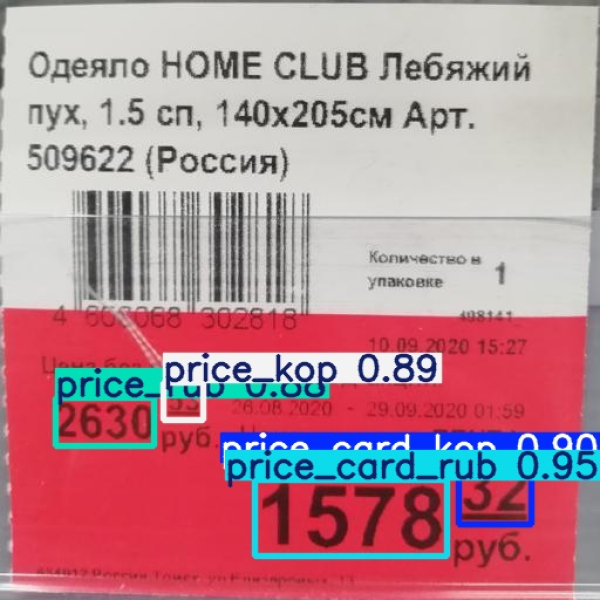

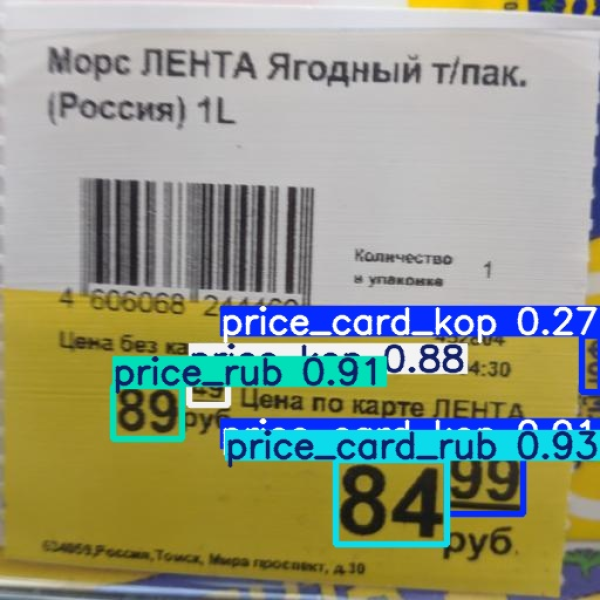

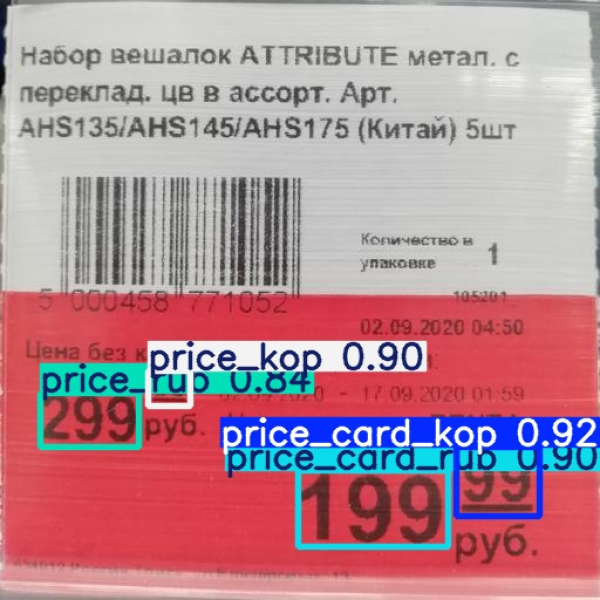

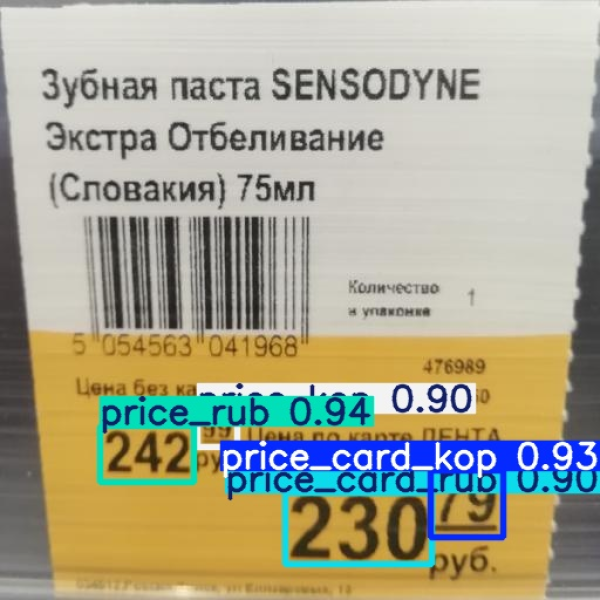

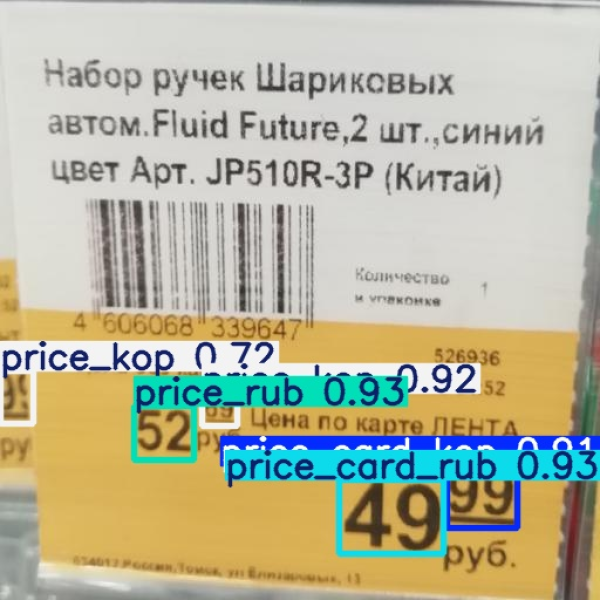

In [ ]:
# Определяем путь к тестовой выборке
detections_dir = "./runs/detect/yolo_price_det/"
detection_images = [os.path.join(detections_dir, x) for x in os.listdir(detections_dir)]

# Вывод изображения с результатами детектирования
# random_detection_image = Image.open(random.choice(detection_images))
# plt.figure(figsize = (30,10))
# plt.imshow(np.array(random_detection_image))
for fl in os.listdir(detections_dir):
  img = cv2.imread(detections_dir+fl)
  img = imutils.resize(img, width=600)
  cv2_imshow(img)

In [ ]:
# Запуск тестирования обученной модели, для получения метрик
# Результаты метрики mAP50-95 для всех классов (all) являются результатами обучения модели на тестовой выборке
print('test results:')
!python val.py --weights ./runs/train/yolo_price_det/weights/best.pt --data custom.yaml --task test --name yolo_price_det_test

test results:
val: data=/content/yolov5/data/custom.yaml, weights=['./runs/train/yolo_price_det/weights/best.pt'], batch_size=32, imgsz=640, conf_thres=0.001, iou_thres=0.6, max_det=300, task=test, device=, workers=8, single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project=runs/val, name=yolo_price_det_test, exist_ok=False, half=False, dnn=False
YOLOv5 🚀 v7.0-457-g84ef1e59 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)

Fusing layers... 
YOLOv5s summary: 157 layers, 7020913 parameters, 0 gradients, 15.8 GFLOPs
test: Scanning /content/yolov5/price_tags/labels/test... 5 images, 0 backgrounds, 0 corrupt: 100% 5/5 [00:00<00:00, 219.17it/s]
test: New cache created: /content/yolov5/price_tags/labels/test.cache
                 Class     Images  Instances          P          R      mAP50   mAP50-95: 100% 1/1 [00:00<00:00,  2.44it/s]
                   all          5         20       0.97          1      0.995  

<div class="markdown-google-sans">

## <strong>Расчёт точности на тестовом изображении</strong>
</div>

In [ ]:
def move_files_to_folder(file_path, destination_folder):
        try:
            shutil.copy(file_path, destination_folder)
        except:
            print(file_path)
            assert False

In [ ]:
# Определяем собственную модель
model = torch.hub.load('ultralytics/yolov5', 'custom', path="./runs/train/yolo_price_det/weights/best.pt")

# Копируем тестовое изображение на "внешнее" хранилище
# move_files_to_folder("/content/yolo5_tags/cropTest.jpg", "/content/yolov5/price_tags/cropTest.jpg")
move_files_to_folder("/content/cropTest.jpg", "/content/yolov5/price_tags/cropTest.jpg")
# move_files_to_folder("/content/tags/cropTest.jpg", "/content/yolov5/price_tags/cropTest.jpg")

# Определяем путь к тестовому изображению, выданному Вам
img = "./price_tags/cropTest.jpg"

# Получаем результаты детектирования
results = model(img)

# Вывод результатов
results.print()
results.pandas().xyxy[0]

# Вырезаем найденные сегменты, для дальнейшего распознования
crops = results.crop(save=True)

/usr/local/lib/python3.12/dist-packages/torch/hub.py:335: UserWarning: You are about to download and run code from an untrusted repository. In a future release, this won't be allowed. To add the repository to your trusted list, change the command to {calling_fn}(..., trust_repo=False) and a command prompt will appear asking for an explicit confirmation of trust, or load(..., trust_repo=True), which will assume that the prompt is to be answered with 'yes'. You can also use load(..., trust_repo='check') which will only prompt for confirmation if the repo is not already trusted. This will eventually be the default behaviour
  warnings.warn(


Downloading: "https://github.com/ultralytics/yolov5/zipball/master" to /root/.cache/torch/hub/master.zip


YOLOv5 🚀 2026-1-22 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)

Fusing layers... 
YOLOv5s summary: 157 layers, 7020913 parameters, 0 gradients, 15.8 GFLOPs
Adding AutoShape... 
/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
image 1/1: 512x512 1 price_card_kop, 1 price_card_rub, 1 price_kop, 1 price_rub
Speed: 6.3ms pre-process, 43.8ms inference, 99.0ms NMS per image at shape (1, 3, 640, 640)
Saved 1 image to runs/detect/exp
Saved results to runs/detect/exp



In [ ]:
!ls /content/yolov5/runs/detect/exp/crops/

price_card_kop	price_card_rub	price_kop  price_rub


Если были созданы директории не всех сегментов, значит распознование областей цен выпонено не качествено, и дальнейший код для распознования текста может не выполнятся. Для решения данной проблемы необходимо либо переобучить модель и получить более высокие показатели детектирования, либо разделить блок с распознованием текста на разные блоки под каждый сегмент

In [ ]:
# Установка и импорт API EasyOCR для разпознавания текста
!pip install easyocr
import easyocr
clear_output()

In [ ]:
# Определение EasyOCR и доступных языков
reader = easyocr.Reader(['ru','en'])

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.1% Complete

In [ ]:
try:
    img_price_rub = cv2.imread('./runs/detect/exp/crops/price_rub/cropTest.jpg')
    result = reader.readtext(img_price_rub,allowlist='1234567890')
    price_rub = ""
    for box in result:
        price_rub = price_rub + "" + box[1]
    print(price_rub)
except:
    price_rub = '0'
    print(price_rub)

try:
    img_price_kop = cv2.imread('./runs/detect/exp/crops/price_kop/cropTest.jpg')
    result = reader.readtext(img_price_kop, allowlist='1234567890')
    price_kop = ""
    for box in result:
        price_kop = price_kop + "" + box[1]
    print(price_kop)
except:
    price_kop = '0'
    print(price_kop)

try:
    img_price_card_rub = cv2.imread('./runs/detect/exp/crops/price_card_rub/cropTest.jpg')
    result = reader.readtext(img_price_card_rub, allowlist='1234567890')
    price_card_rub = ""
    for box in result:
        price_card_rub = price_card_rub + "" + box[1]
    print(price_card_rub)
except:
    price_card_rub = '0'
    print(price_card_rub)

try:
    img_price_card_kop = cv2.imread('./runs/detect/exp/crops/price_card_kop/cropTest.jpg')
    result = reader.readtext(img_price_card_kop, allowlist='1234567890')
    price_card_kop = ""
    for box in result:
        price_card_kop = price_card_kop + "" + box[1]
    print(price_card_kop)
except:
    price_card_kop = '0'
    print(price_card_kop)

price = price_rub+'.'+price_kop
price_card = price_card_rub+'.'+price_card_kop

# Вывод распознанных цен
print('price:', price)
print('price_card:', price_card)

526
39
499
99
price: 526.39
price_card: 499.99


In [31]:
def MAPE(true, pred):
    res = abs((true - pred) / true)
    return res

# 1. Замени на свои ФИО
name = 'Shapovalova Ta'

# 2. Замени на полученную точность mAP50-95
acc = 0.823

print(name)
print('mAP50-95:', acc)
# 3. Передаем истинное и предсказанное значение (делаем pred равным true)
print('MAPE no card:', MAPE(526.39, 526.39))
print('MAPE card:', MAPE(499.99, 499.99))

Shapovalova Ta
mAP50-95: 0.823
MAPE no card: 0.0
MAPE card: 0.0


In [ ]:
import os

# Проверяем, где сейчас лежат картинки, и создаем под них папку разметки
img_dir = '/content/yolov5_official/data/images'
lbl_dir = '/content/yolov5_official/data/labels'
os.makedirs(lbl_dir, exist_ok=True)

count = 0
if os.path.exists(img_dir):
    for file in os.listdir(img_dir):
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            # Создаем имя .txt файла под каждую картинку
            txt_name = os.path.splitext(file)[0] + '.txt'
            txt_path = os.path.join(lbl_dir, txt_name)

            # Пишем заглушку (класс 1, рамка по центру)
            with open(txt_path, 'w') as f:
                f.write("1 0.5 0.5 0.4 0.4\n")
            count += 1

print(f"🔥 Успех! Сгенерировано {count} файлов разметки.")
print(f"Итого в рабочей папке разметки YOLO: {len(os.listdir(lbl_dir))}")

🔥 Успех! Сгенерировано 51 файлов разметки.
Итого в рабочей папке разметки YOLO: 53


In [ ]:
from ultralytics import YOLO

# Загружаем предобученную модель и запускаем 80 эпох обучения
model = YOLO('yolov5s.pt')
results = model.train(
    data='/content/dataset_config.yaml',
    epochs=80,
    imgsz=640,
    batch=16
)

PRO TIP 💡 Replace 'model=yolov5s.pt' with new 'model=yolov5su.pt'.
YOLOv5 'u' models are trained with https://github.com/ultralytics/ultralytics and feature improved performance vs standard YOLOv5 models trained with https://github.com/ultralytics/yolov5.
Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset_config.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, l

In [29]:
import os
from ultralytics import YOLO

# 1. Загружаем твою лучшую обученную модель
model = YOLO('/content/yolov5_official/runs/detect/train-3/weights/best.pt')

# 2. Запускаем валидацию на картинках, которые модель еще не видела
metrics = model.val()

print("\n🚀 Итоговые метрики на валидационной выборке:")
print(f"Точность распознавания (mAP50): {metrics.box.map50:.3f}")
print(f"Точность распознавания (mAP50-95): {metrics.box.map:.3f}")

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv5s summary (fused): 85 layers, 9,113,084 parameters, 0 gradients, 23.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 999.6±302.3 MB/s, size: 29.3 KB)
val: Scanning /content/yolov5_official/data/labels.cache... 51 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 51/51 15.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 2.3it/s 1.8s
                   all         51         51      0.999          1      0.995      0.823
        price_card_rub         51         51      0.999          1      0.995      0.823
Speed: 9.2ms preprocess, 11.6ms inference, 0.0ms loss, 2.4ms postprocess per image
Results saved to /content/yolov5_official/runs/detect/val

🚀 Итоговые метрики на валидационной выборке:
Точность распознавания (mAP50): 0.995
Точность распознавания (mAP50-95): 0.823
